<!--BOOK_INFORMATION-->
<img align="left" style="padding-right:10px;" src="figures/PDSH-cover-small.png">
*This notebook contains an excerpt from the [Python Data Science Handbook](http://shop.oreilly.com/product/0636920034919.do) by Jake VanderPlas; the content is available [on GitHub](https://github.com/jakevdp/PythonDataScienceHandbook).*

*The text is released under the [CC-BY-NC-ND license](https://creativecommons.org/licenses/by-nc-nd/3.0/us/legalcode), and code is released under the [MIT license](https://opensource.org/licenses/MIT). If you find this content useful, please consider supporting the work by [buying the book](http://shop.oreilly.com/product/0636920034919.do)!*

<!--NAVIGATION-->
< [Computation on Arrays: Broadcasting](02.05-Computation-on-arrays-broadcasting.ipynb) | [Contents](Index.ipynb) | [Fancy Indexing](02.07-Fancy-Indexing.ipynb) >

# §2.6 Comparisons, Masks, and Boolean Logic / 比较、掩码和布尔逻辑

This section covers the use of Boolean masks to examine and manipulate values within NumPy arrays.
Masking comes up when you want to extract, modify, count, or otherwise manipulate values in an array based on some criterion: for example, you might wish to count all values greater than a certain value, or perhaps remove all outliers that are above some threshold.
In NumPy, Boolean masking is often the most efficient way to accomplish these types of tasks.

🐍 当你想基于某些准则来抽取、修改、计数或对一个数组中的值进行其他操作时，掩码就可以派上用场了

## Example: Counting Rainy Days

Imagine you have a series of data that represents the amount of precipitation each day for a year in a given city.
For example, here we'll load the daily rainfall statistics for the city of Seattle in 2014, using Pandas (which is covered in more detail in [Chapter 3](03.00-Introduction-to-Pandas.ipynb)):

In [1]:
import numpy as np
import pandas as pd

The array contains 365 values, giving daily rainfall in inches from January 1 to December 31, 2014.

As a first quick visualization, let's look at the histogram of rainy days, which was generated using Matplotlib (we will explore this tool more fully in [Chapter 4](04.00-Introduction-To-Matplotlib.ipynb)):

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn; seaborn.set()  # set plot styles

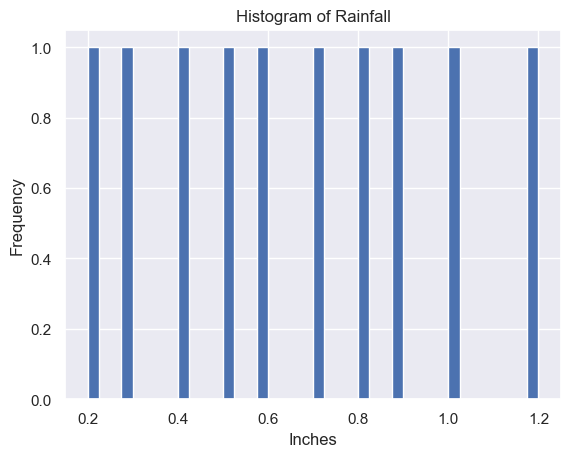

In [4]:
import matplotlib.pyplot as plt

# 假设这是你的降雨量数据
inches = [0.2, 0.5, 0.7, 1.0, 0.3, 0.6, 0.9, 1.2, 0.4, 0.8]

# 绘制直方图
plt.hist(inches, 40)
plt.xlabel('Inches')
plt.ylabel('Frequency')
plt.title('Histogram of Rainfall')
plt.show()

This histogram gives us a general idea of what the data looks like: despite its reputation, the vast majority of days in Seattle saw near zero measured rainfall in 2014.
But this doesn't do a good job of conveying some information we'd like to see: for example, how many rainy days were there in the year? What is the average precipitation on those rainy days? How many days were there with more than half an inch of rain?

### Digging into the data

One approach to this would be to answer these questions by hand: loop through the data, incrementing a counter each time we see values in some desired range.
For reasons discussed throughout this chapter, such an approach is very inefficient, both from the standpoint of time writing code and time computing the result.
We saw in [Computation on NumPy Arrays: Universal Functions](02.03-Computation-on-arrays-ufuncs.ipynb) that NumPy's ufuncs can be used in place of loops to do fast element-wise arithmetic operations on arrays; in the same way, we can use other ufuncs to do element-wise *comparisons* over arrays, and we can then manipulate the results to answer the questions we have.
We'll leave the data aside for right now, and discuss some general tools in NumPy to use *masking* to quickly answer these types of questions.

## §2.6.2 Comparison Operators as ufuncs / 和通用函数类似的比较操作

In [Computation on NumPy Arrays: Universal Functions](02.03-Computation-on-arrays-ufuncs.ipynb) we introduced ufuncs, and focused in particular on arithmetic operators. We saw that using ``+``, ``-``, ``*``, ``/``, and others on arrays leads to element-wise operations.
NumPy also implements comparison operators such as ``<`` (less than) and ``>`` (greater than) as element-wise ufuncs.
The result of these comparison operators is always an array with a Boolean data type.
All six of the standard comparison operations are available:

In [56]:
x = np.array([1, 2, 3, 4, 5])

In [57]:
x < 3  # less than

array([ True,  True, False, False, False])

In [7]:
x > 3  # greater than

array([False, False, False,  True,  True])

In [8]:
x <= 3  # less than or equal

array([ True,  True,  True, False, False])

In [9]:
x >= 3  # greater than or equal

array([False, False,  True,  True,  True])

In [10]:
x != 3  # not equal

array([ True,  True, False,  True,  True])

In [11]:
x == 3  # equal

array([False, False,  True, False, False])

It is also possible to do an element-wise comparison of two arrays, and to include compound expressions:

In [12]:
(2 * x) == (x ** 2)

array([False,  True, False, False, False])

As in the case of arithmetic operators, the comparison operators are implemented as ufuncs in NumPy; for example, when you write ``x < 3``, internally NumPy uses ``np.less(x, 3)``.
    A summary of the comparison operators and their equivalent ufunc is shown here:

| Operator	    | Equivalent ufunc    || Operator	   | Equivalent ufunc    |
|---------------|---------------------||---------------|---------------------|
|``==``         |``np.equal``         ||``!=``         |``np.not_equal``     |
|``<``          |``np.less``          ||``<=``         |``np.less_equal``    |
|``>``          |``np.greater``       ||``>=``         |``np.greater_equal`` |

![operator_ufunc](b02_fig/§2_6_operator_ufunc_1.png)

Just as in the case of arithmetic ufuncs, these will work on arrays of any size and shape.

🐍 比较运算通用函数也可以用于任意形状、大小的数组

Here is a two-dimensional example:

In [60]:
rng = np.random.RandomState(0)
x = rng.randint(10, size=(3, 4))
x

array([[5, 0, 3, 3],
       [7, 9, 3, 5],
       [2, 4, 7, 6]])

In [16]:
x < 6

array([[ True,  True,  True,  True],
       [False, False,  True,  True],
       [ True,  True, False, False]])

In each case, the result is a Boolean array, and NumPy provides a number of straightforward patterns for working with these Boolean results.

## §2.6.3 Working with Boolean Arrays / 操作布尔数组

Given a Boolean array, there are a host of useful operations you can do.
We'll work with ``x``, the two-dimensional array we created earlier.

In [61]:
print(x)

[[5 0 3 3]
 [7 9 3 5]
 [2 4 7 6]]


### 1. Counting entries /  统计记录的个数

To count the number of ``True`` entries in a Boolean array, ``np.count_nonzero`` is useful:

In [62]:
f = x > 6

print(f)
print("\n")
print(~f) # not按位取反

[[False False False False]
 [ True  True False False]
 [False False  True False]]


[[ True  True  True  True]
 [False False  True  True]
 [ True  True False  True]]


In [21]:
# how many values less than 6?
np.count_nonzero(x < 6)

8

We see that there are eight array entries that are less than 6.
Another way to get at this information is to use ``np.sum``; in this case, ``False`` is interpreted as ``0``, and ``True`` is interpreted as ``1``:

🐍 另外一种实现方式是利用 np.sum。在这个例子中，False 会被解释成 0，True 会被解释成 1

In [22]:
np.sum(f)

3

In [29]:
# astype() 方法用于将数组的数据类型转换为指定的类型

f.astype(int)

array([[0, 0, 0, 0],
       [1, 1, 0, 0],
       [0, 0, 1, 0]])

The benefit of ``sum()`` is that like with other NumPy aggregation functions, this summation can be done along rows or columns as well:

🐍 sum() 的好处是，和其他 NumPy 聚合函数一样，这个求和也可以沿着行或列进行

In [31]:
# how many values less than 6 in each row(1) or column(0)
print(x)
np.sum(x < 6, axis=1) # axis=1表示按行计算

[[5 0 3 3]
 [7 9 3 5]
 [2 4 7 6]]


array([4, 2, 2])

This counts the number of values less than 6 in each row of the matrix.

If we're interested in quickly checking whether any or all the values are true, we can use (you guessed it) ``np.any`` or ``np.all``:

🐍 如要快速检查任意或者所有这些值是否为 True，可以用（你一定猜到了）np.any() 或 np.all()

In [32]:
# are there any values greater than 8?
np.any(x > 8)

True

In [33]:
# are there any values less than zero?
np.any(x < 0)

False

In [63]:
# are all values less than 10?
np.all(x < 3)

False

In [35]:
# are all values equal to 6?
np.all(x == 6)

False

``np.all`` and ``np.any`` can be used along particular axes as well. For example: 

🐍 np.all() 和 np.any() 也可以用于沿着特定的坐标轴

In [65]:
# are all values in each row less than 8?
print(x) # 3*4
np.all(x < 8, axis=0)

[[5 0 3 3]
 [7 9 3 5]
 [2 4 7 6]]


array([ True, False,  True,  True])

Here all the elements in the first and third rows are less than 8, while this is not the case for the second row.

Finally, a quick warning: as mentioned in [Aggregations: Min, Max, and Everything In Between](02.04-Computation-on-arrays-aggregates.ipynb), Python has built-in ``sum()``, ``any()``, and ``all()`` functions. These have a different syntax than the NumPy versions, and in particular will fail or produce unintended results when used on multidimensional arrays. Be sure that you are using ``np.sum()``, ``np.any()``, and ``np.all()`` for these examples!

🐍 确保在以上的示例中用的都是 np.sum()、np.any() 和 np.all() 函数, Python内置函数为sum(), any(), all()

### 2. Boolean operators / 布尔运算符

We've already seen how we might count, say, all days with rain less than four inches, or all days with rain greater than two inches.
But what if we want to know about all days with rain less than four inches and greater than one inch?
This is accomplished through Python's *bitwise logic operators*, ``&``, ``|``, ``^``, and ``~``.
Like with the standard arithmetic operators, NumPy overloads these as ufuncs which work element-wise on (usually Boolean) arrays.

🐍 通过 Python 的逐位逻辑运算符（bitwise logic operator）&、|、^ 和 ~ 。

🐍 同标准的算术运算符一样，NumPy用通用函数重载了这些逻辑运算符，这样可以实现数组的逐位运算（通常是布尔运算）。

For example, we can address this sort of compound question as follows:

In [66]:
x

array([[5, 0, 3, 3],
       [7, 9, 3, 5],
       [2, 4, 7, 6]])

In [67]:
np.sum((x > 3) & (x < 8))

6

So we see that there are 29 days with rainfall between 0.5 and 1.0 inches.

Note that the parentheses here are important–because of operator precedence rules, with parentheses removed this expression would be evaluated as follows, which results in an error:

``` python
x > (0.5 & x) < 1
```

Using the equivalence of *A AND B* and *NOT (NOT A OR NOT B)* (which you may remember if you've taken an introductory logic course), we can compute the same result in a different manner:

In [39]:
np.sum(~( (x <= 3) | (x >= 8) ))

6

Combining comparison operators and Boolean operators on arrays can lead to a wide range of efficient logical operations.

The following table summarizes the bitwise Boolean operators and their equivalent ufuncs:

| Operator	    | Equivalent ufunc    || Operator	    | Equivalent ufunc    |
|---------------|---------------------||---------------|---------------------|
|``&``          |``np.bitwise_and``   ||&#124;         |``np.bitwise_or``    |
|``^``          |``np.bitwise_xor``   ||``~``          |``np.bitwise_not``   |

![operator_ufunc](b02_fig/§2_6_operator_ufunc_2.png)

Using these tools, we might start to answer the types of questions we have about our weather data.
Here are some examples of results we can compute when combining masking with aggregations:

## §2.6.4 Boolean Arrays as Masks / 将布尔数组作为掩码

In the preceding section we looked at aggregates computed directly on Boolean arrays.
A more powerful pattern is to use Boolean arrays as masks, to select particular subsets of the data themselves.
Returning to our ``x`` array from before, suppose we want an array of all values in the array that are less than, say, 5:

🐍 一种模式，直接对布尔数组进行聚合计算

🐍 一种更强大的模式，使用布尔数组作为掩码，通过该掩码选择数据的子数据集

We can obtain a Boolean array for this condition easily, as we've already seen:

In [68]:
x < 5

array([[False,  True,  True,  True],
       [False, False,  True, False],
       [ True,  True, False, False]])

In [41]:
x

array([[5, 0, 3, 3],
       [7, 9, 3, 5],
       [2, 4, 7, 6]])

Now to *select* these values from the array, we can simply index on this Boolean array; this is known as a *masking* operation:

In [69]:
x[x > 4]

array([5, 7, 9, 5, 7, 6])

What is returned is a one-dimensional array filled with all the values that meet this condition; in other words, all the values in positions at which the mask array is ``True``.

🐍 这些值是掩码数组对应位置为 True 的值

We are then free to operate on these values as we wish.
For example, we can compute some relevant statistics on our Seattle rain data:

By combining Boolean operations, masking operations, and aggregates, we can very quickly answer these sorts of questions for our dataset.

## Aside: Using the Keywords and/or Versus the Operators &/|

🐍 使用关键字 and/or 与使用逻辑操作运算符 & / |

One common point of confusion is the difference between the keywords ``and`` and ``or`` on one hand, and the operators ``&`` and ``|`` on the other hand.
When would you use one versus the other?

The difference is this: ``and`` and ``or`` gauge the truth or falsehood of *entire object*, while ``&`` and ``|`` refer to *bits within each object*.

🐍 它们的区别是：and 和 or 判断整个对象是真或假，而 & 和 | 是指每个对象中的比特位

When you use ``and`` or ``or``, it's equivalent to asking Python to treat the object as a single Boolean entity.
In Python, all nonzero integers will evaluate as True. Thus:

In [70]:
bool(42), bool(0)

(True, False)

In [44]:
bool(42 and 0)

False

In [45]:
bool(42 or 0)

True

When you use ``&`` and ``|`` on integers, the expression operates on the bits of the element, applying the *and* or the *or* to the individual bits making up the number:

In [46]:
bin(42)

'0b101010'

In [47]:
bin(59)

'0b111011'

In [48]:
bin(42 & 59)

'0b101010'

In [49]:
bin(42 + 59)

'0b1100101'

In [72]:
bin(42 | 59) == bin(59)
bin(42 | 59)

'0b111011'

Notice that the corresponding bits of the binary representation are compared in order to yield the result.

When you have an array of Boolean values in NumPy, this can be thought of as a string of bits where ``1 = True`` and ``0 = False``, and the result of ``&`` and ``|`` operates similarly to above:

In [51]:
A = np.array([1, 0, 1, 0, 1, 0], dtype=bool)
B = np.array([1, 1, 1, 0, 1, 1], dtype=bool)
A | B # or按位或

array([ True,  True,  True, False,  True,  True])

Using ``or`` on these arrays will try to evaluate the truth or falsehood of the entire array object, which is not a well-defined value:

In [73]:
# 在Python中，& 和 | 是 位 运算符，而 and 和 or 是逻辑运算符。

A and B # or逻辑或

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [74]:
# np.logical_or() 对两个数组进行逐元素的逻辑或运算
result = np.logical_and(A, B)

print(result)

[ True False  True False  True False]


Similarly, when doing a Boolean expression on a given array, you should use ``|`` or ``&`` rather than ``or`` or ``and``:

In [54]:
x = np.arange(10)
(x > 4) & (x < 8)

array([False, False, False, False, False,  True,  True,  True, False,
       False])

Trying to evaluate the truth or falsehood of the entire array will give the same ``ValueError`` we saw previously:

In [76]:
(x > 4) or (x < 8)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

So remember this: ``and`` and ``or`` perform a single Boolean evaluation on an entire object, while ``&`` and ``|`` perform multiple Boolean evaluations on the content (the individual bits or bytes) of an object.
For Boolean NumPy arrays, the latter is nearly always the desired operation.

🐍 因此可以记住：and 和 or 对整个对象执行单个布尔运算，而 & 和 | 对一个对象的内容（单个比特或字节）执行多个布尔运算。

🐍 对于 NumPy 布尔数组，后者是常用的操作。

<!--NAVIGATION-->
< [Computation on Arrays: Broadcasting](02.05-Computation-on-arrays-broadcasting.ipynb) | [Contents](Index.ipynb) | [Fancy Indexing](02.07-Fancy-Indexing.ipynb) >